### STEP 1 数据准备 (DATA PREPROCESSING)

In [59]:
# STEP 1 导入基础库

# 导入常用库
import pandas as pd
import numpy as np

# 画图以后会用到（现在可以先不画）
import matplotlib.pyplot as plt

# 之后标准化会用到
from sklearn.preprocessing import StandardScaler

In [60]:
# STEP 2 读取数据
# ====== 读取原始数据 ======
# 假设 data.csv 和你的 notebook 在同一目录下
file_path = 'E:\SEP767 Project\data.csv'   # 如果不在同一路径，改成自己的绝对/相对路径
data_raw = pd.read_csv(file_path)

# 看一下数据前5行
data_raw.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [61]:
# 查看数据的基本信息：行数、列数、每列类型
print("数据形状（行, 列）:", data_raw.shape)
print("\n各列数据类型：")
print(data_raw.dtypes)


数据形状（行, 列）: (569, 33)

各列数据类型：
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst       

In [62]:
# STEP 3 删除无用列
'''
原始数据里一般会有两类不需要用于模型的列：
id：只是编号，没有信息
Unnamed: 32：空列，全是 NaN（如果有的话）
'''
# ====== 删除无用列 ======
data = data_raw.copy()

# 列出当前所有列名，方便你检查
print("原始列名：")
print(data.columns.tolist())

# delete id and Unnamed: 32 if exists
cols_to_drop = []

if "id" in data.columns:
    cols_to_drop.append("id")
if "Unnamed: 32" in data.columns:
    cols_to_drop.append("Unnamed: 32")

data = data.drop(columns=cols_to_drop)

print("\n删除无用列后的列名：")
print(data.columns.tolist())
print("当前数据形状:", data.shape)

原始列名：
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

删除无用列后的列名：
['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'peri

In [63]:
# STEP 4 处理标签列 diagnosis
'''
B（benign，良性）→ 0
M（malignant，恶性）→ 1
'''
# ====== 处理标签列 diagnosis ======
# 先看一下 diagnosis 列的取值情况
print(data["diagnosis"].value_counts())

# 用 map 把字符标签映射为数字
label_map = {"B": 0, "M": 1}
data["diagnosis_num"] = data["diagnosis"].map(label_map)

# 检查一下新列
print("\n映射后的标签统计：")
print(data["diagnosis_num"].value_counts())

# 可以选择保留原始 diagnosis 列，方便画图时直接用 B/M
# 也可以只在建模时使用 diagnosis_num


diagnosis
B    357
M    212
Name: count, dtype: int64

映射后的标签统计：
diagnosis_num
0    357
1    212
Name: count, dtype: int64


In [64]:
# STEP 5 分离矩阵特征 X和标签 y

# ====== split X y ======
# feature columns：all numerical features except diagnosis and diagnosis_num
feature_cols = [col for col in data.columns 
                if col not in ["diagnosis", "diagnosis_num"]]

X = data[feature_cols]
y = data["diagnosis_num"]

print("dimension X:", X.shape)
print("dimension y:", y.shape)

# 简单看一下特征的前几行
X.head()

dimension X: (569, 30)
dimension y: (569,)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [65]:
# STEP 6 标准化特征
# 目标：每个特征都变成 均值0、标准差1，为 PCA 和 PLS 做准备。
# ====== standardized features ======
scaler = StandardScaler()

# 注意：fit_transform 返回的是 numpy 数组
X_scaled_array = scaler.fit_transform(X)

# 为了后续使用方便，再转换回 DataFrame，并保留列名
X_scaled = pd.DataFrame(X_scaled_array, columns=feature_cols)

print("标准化后特征的均值（接近0）：")
print(X_scaled.mean().round(3).head())

print("\n标准化后特征的标准差（接近1）：")
print(X_scaled.std().round(3).head())

# 看一下标准化后的前几行
X_scaled.head()

标准化后特征的均值（接近0）：
radius_mean       -0.0
texture_mean       0.0
perimeter_mean    -0.0
area_mean         -0.0
smoothness_mean   -0.0
dtype: float64

标准化后特征的标准差（接近1）：
radius_mean        1.001
texture_mean       1.001
perimeter_mean     1.001
area_mean          1.001
smoothness_mean    1.001
dtype: float64


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [66]:
print("Step 1 data preprocessing！X_scaled :", X_scaled.shape, "  y :", y.shape)


Step 1 data preprocessing！X_scaled : (569, 30)   y : (569,)


### STEP 2 — 初步探索（Exploratory Data Visualization）

In [67]:
# STEP 7 先导入绘图库
import matplotlib.pyplot as plt
import seaborn as sns

# 设置图形风格
sns.set(style="whitegrid")


In [68]:
# 快速看一下特征信息
# ====== 查看部分描述统计 ======
print(X.describe().round(2))

       radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
count       569.00        569.00          569.00     569.00           569.00   
mean         14.13         19.29           91.97     654.89             0.10   
std           3.52          4.30           24.30     351.91             0.01   
min           6.98          9.71           43.79     143.50             0.05   
25%          11.70         16.17           75.17     420.30             0.09   
50%          13.37         18.84           86.24     551.10             0.10   
75%          15.78         21.80          104.10     782.70             0.11   
max          28.11         39.28          188.50    2501.00             0.16   

       compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
count            569.00          569.00               569.00         569.00   
mean               0.10            0.09                 0.05           0.18   
std                0.05            0.08   

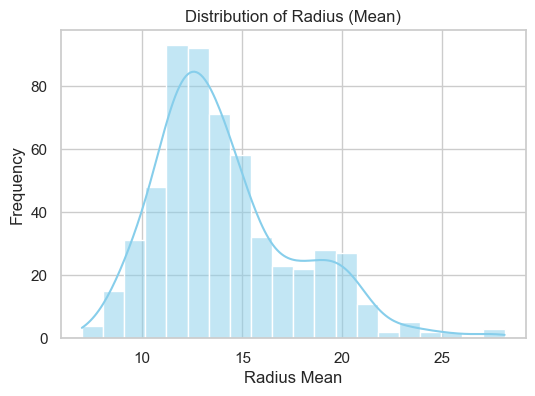

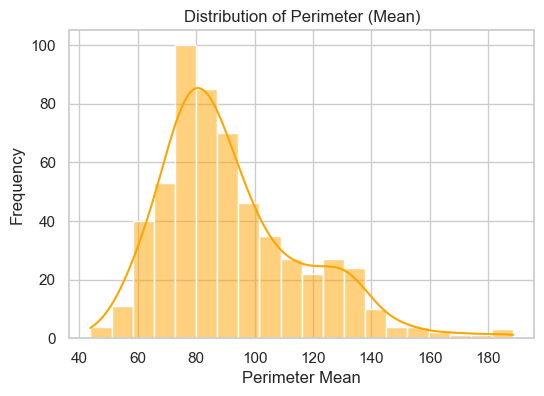

C:\Users\admin\AppData\Local\Temp\ipykernel_47292\280411087.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=data_raw, palette=['#66c2a5','#fc8d62'])


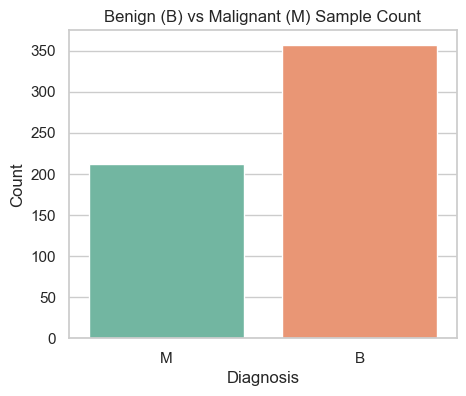

In [69]:
# STEP 8 绘制

# histogram for radius_mean
# ====== 图1：半径（radius_mean）分布 ======
plt.figure(figsize=(6,4))
sns.histplot(data_raw['radius_mean'], bins=20, kde=True, color='skyblue')

plt.title("Distribution of Radius (Mean)")
plt.xlabel("Radius Mean")
plt.ylabel("Frequency")
plt.show()

# histogram for perimeter_mean
# ====== 图2：周长（perimeter_mean）分布 ======
plt.figure(figsize=(6,4))
sns.histplot(data_raw['perimeter_mean'], bins=20, kde=True, color='orange')

plt.title("Distribution of Perimeter (Mean)")
plt.xlabel("Perimeter Mean")
plt.ylabel("Frequency")
plt.show()

# # ====== 图3：诊断标签计数柱状图 ======
plt.figure(figsize=(5,4))
sns.countplot(x='diagnosis', data=data_raw, palette=['#66c2a5','#fc8d62'])

plt.title("Benign (B) vs Malignant (M) Sample Count")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

### STEP 3 PCA分析

In [70]:
# STEP 9 导入PCA库
from sklearn.decomposition import PCA
# 保证已经有如下变量！！！
# X_scaled   # 标准化后的特征
# y          # B/M 标签
# data       # 含 diagnosis 列

In [71]:
# STEP 10 运行PCA
# ====== Run PCA ======
pca = PCA()
pca.fit(X_scaled)

# 获取PCA后的样本坐标 (scores)
X_pca = pca.transform(X_scaled)

print("原始维度:", X_scaled.shape)
print("PCA 变换后维度:", X_pca.shape)

原始维度: (569, 30)
PCA 变换后维度: (569, 30)


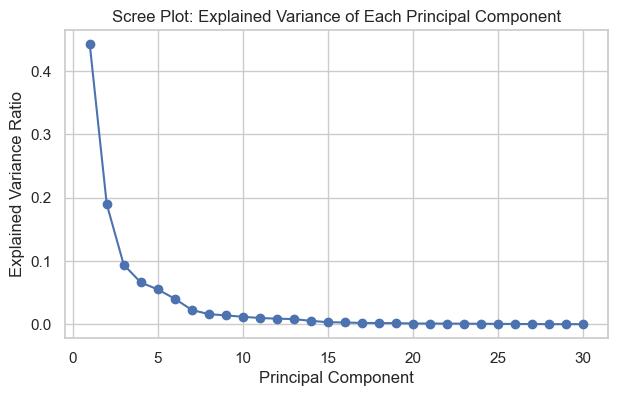

In [72]:
# STEP 11 制作相关图像
# Scree Plot（前几个主成分重要程度分析）
# 告诉我们到底选多少个PC更为合适
# ====== Scree Plot ======
plt.figure(figsize=(7,4))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_, 'o-')

plt.title("Scree Plot: Explained Variance of Each Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()

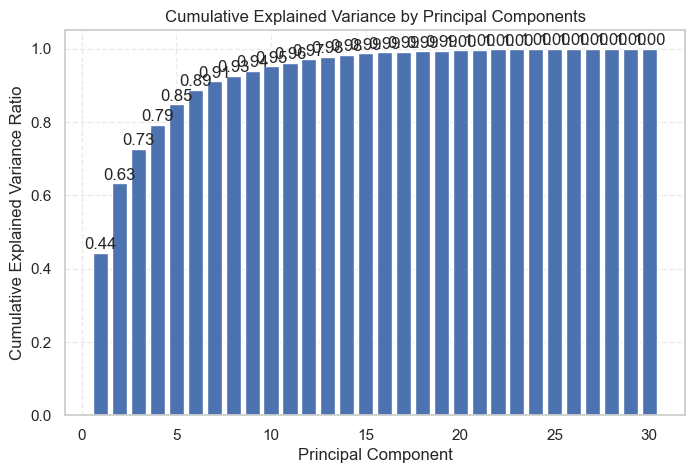

In [73]:
# ===== Cumulative Explained Variance (Bar Plot) =====
import numpy as np
import matplotlib.pyplot as plt

# PCA 结果：pca.explained_variance_ratio_
evr = pca.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(cumulative_evr) + 1), cumulative_evr)

plt.title("Cumulative Explained Variance by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance Ratio")

# 显示数值标签
for i, v in enumerate(cumulative_evr):
    plt.text(i + 1, v + 0.01, f"{v:.2f}", ha='center')

plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

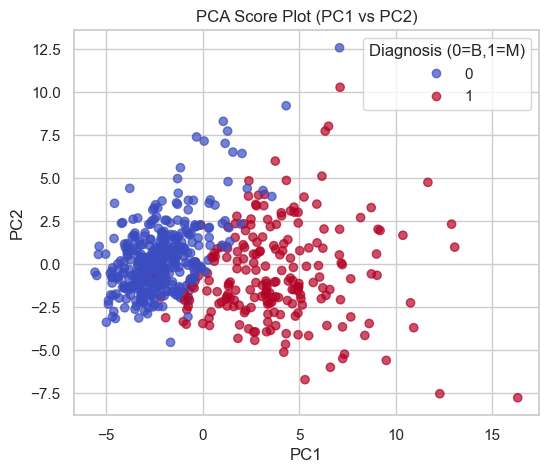

In [74]:
# PCA Score Plot PC1 vs PC2，点颜色按B/M
# ====== PCA Score Plot (PC1 vs PC2) ======
plt.figure(figsize=(6,5))

# 根据诊断着色
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], 
                      c=y, cmap="coolwarm", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Score Plot (PC1 vs PC2)")
plt.legend(*scatter.legend_elements(), title="Diagnosis (0=B,1=M)")
plt.grid(True)
plt.show()


In [75]:
# PCA Loadings Plot
# ====== PCA Loadings ======
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f"PC{i+1}" for i in range(len(pca.components_))],
                        index=X_scaled.columns)

print("first two PC loadings：")
loadings.iloc[:, :2].head()


first two PC loadings：


,PC1,PC2
radius_mean,0.218902,-0.233857
texture_mean,0.103725,-0.059706
perimeter_mean,0.227537,-0.215181
area_mean,0.220995,-0.231077
smoothness_mean,0.142590,0.186113


In [76]:
X_pca

array([[ 9.19283683e+00,  1.94858307e+00, -1.12316616e+00, ...,
         3.39144536e-02, -4.56477199e-02,  4.71692081e-02],
       [ 2.38780180e+00, -3.76817174e+00, -5.29292687e-01, ...,
        -3.26241827e-02,  5.68742432e-03,  1.86787626e-03],
       [ 5.73389628e+00, -1.07517380e+00, -5.51747593e-01, ...,
        -4.70258247e-02, -3.14589659e-03, -7.50534755e-04],
       ...,
       [ 1.25617928e+00, -1.90229671e+00,  5.62730526e-01, ...,
         2.57775589e-03, -6.70621179e-03, -3.77041667e-03],
       [ 1.03747941e+01,  1.67201011e+00, -1.87702933e+00, ...,
         6.80863833e-02,  8.41632764e-02,  2.37828222e-02],
       [-5.47524330e+00, -6.70636791e-01,  1.49044308e+00, ...,
         9.51587894e-03,  6.09131090e-02,  1.94755854e-02]])

### STEP 4  PCA + CLASSIFICATION (使用RANDOM FOREST)

In [77]:
# STEP 12 PCA + Classification （using Random Forest）
# 提取前三个主成分
# ====== 取 PCA 的前 3 个主成分作为模型输入 ======
# X_pca 是 numpy 数组，现在只取前 3 列（PC1, PC2, PC3）
X_pca_3 = X_pca[:, :3]

print("用于分类的主成分矩阵形状：", X_pca_3.shape)



用于分类的主成分矩阵形状： (569, 3)


In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ====== 划分训练集和测试集 ======
# test_size=0.2 表示 20% 作测试，随机数种子设置为 42，保证结果可复现
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_3, y, test_size=0.2, random_state=42
)

# ====== 定义 Random Forest 模型 ======
rf = RandomForestClassifier(
    n_estimators=200,     # 决策树数量
    max_depth=None,       # 不限制树深度
    random_state=42
)

# ====== 训练模型 ======
rf.fit(X_train, y_train)

# ====== 使用模型进行预测 ======
y_pred = rf.predict(X_test)


In [79]:
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy (using PC1–PC3): {:.4f}".format(accuracy))


Random Forest Accuracy (using PC1–PC3): 0.9561


In [80]:
cm = confusion_matrix(y_test, y_pred)
cm


array([[68,  3],
       [ 2, 41]])

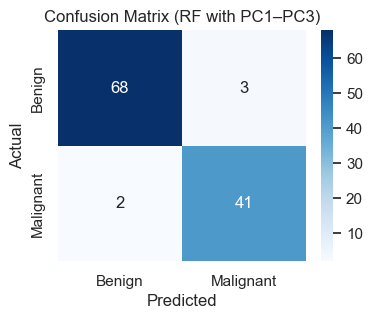

In [81]:
# ====== Confusion Matrix Heatmap ======
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])

plt.title("Confusion Matrix (RF with PC1–PC3)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [82]:
# 使用交叉验证法则 选择最佳PC数量” + 输出曲线/表格
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

# ====== cross-validation set ======
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ====== try different number of compoenents used ======
pc_list = range(1, 11)   # PC # from 1~11
mean_scores = []
std_scores = []

for n_pc in pc_list:
    pipe = Pipeline([
        ("pca", PCA(n_components=n_pc)),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=42))
    ])
    
    scores = cross_val_score(pipe, X_scaled, y, cv=cv, scoring="accuracy")
    mean_scores.append(scores.mean())
    std_scores.append(scores.std())

# ====== 汇总成表格（方便你复制到PPT） ======
cv_result = pd.DataFrame({
    "n_components": list(pc_list),
    "cv_mean_accuracy": mean_scores,
    "cv_std": std_scores
})

print(cv_result)

best_row = cv_result.loc[cv_result["cv_mean_accuracy"].idxmax()]
best_pc = int(best_row["n_components"])
print("\n最佳PC数量（CV mean最高）:", best_pc)
print("对应CV accuracy: {:.4f} ± {:.4f}".format(best_row["cv_mean_accuracy"], best_row["cv_std"]))


   n_components  cv_mean_accuracy    cv_std
0             1          0.876929  0.037406
1             2          0.942059  0.023865
2             3          0.933271  0.030626
3             4          0.936796  0.024989
4             5          0.956094  0.024149
5             6          0.950831  0.023229
6             7          0.954339  0.020264
7             8          0.950831  0.019639
8             9          0.950815  0.020417
9            10          0.954324  0.026233

最佳PC数量（CV mean最高）: 5
对应CV accuracy: 0.9561 ± 0.0241


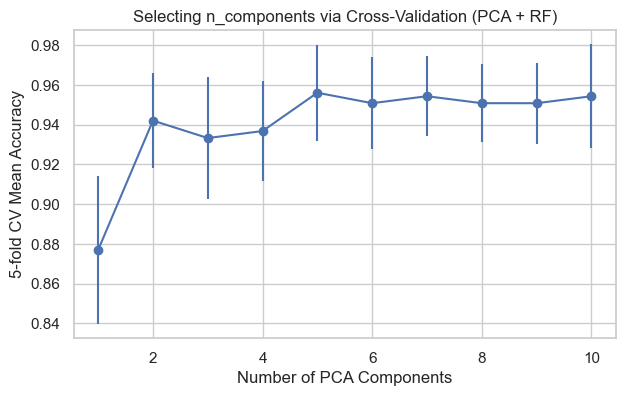

In [83]:
plt.figure(figsize=(7,4))
plt.errorbar(cv_result["n_components"], cv_result["cv_mean_accuracy"], yerr=cv_result["cv_std"], fmt='o-')
plt.xlabel("Number of PCA Components")
plt.ylabel("5-fold CV Mean Accuracy")
plt.title("Selecting n_components via Cross-Validation (PCA + RF)")
plt.grid(True)
plt.show()


### STEP5  PLS-DA golden Rules using three datasets！

Train: (341, 30) Test: (114, 30) Validation: (114, 30)
Train class ratio: {0: 0.628, 1: 0.372}
Test  class ratio: {0: 0.623, 1: 0.377}
Val   class ratio: {0: 0.632, 1: 0.368}

[CV 结果] 不同 LV 的 5-fold CV ROC-AUC：


,lv,cv_mean_auc,cv_std_auc
0,1,0.980291,0.016128
1,2,0.993170,0.007218
2,3,0.991311,0.009324
3,4,0.993680,0.009959
4,5,0.992030,0.010999
5,6,0.992205,0.010311
6,7,0.991285,0.011626
7,8,0.990193,0.010966
8,9,0.991114,0.011156
9,10,0.991481,0.010791



✅ the best optimized LV obtained from cross-validation = 4


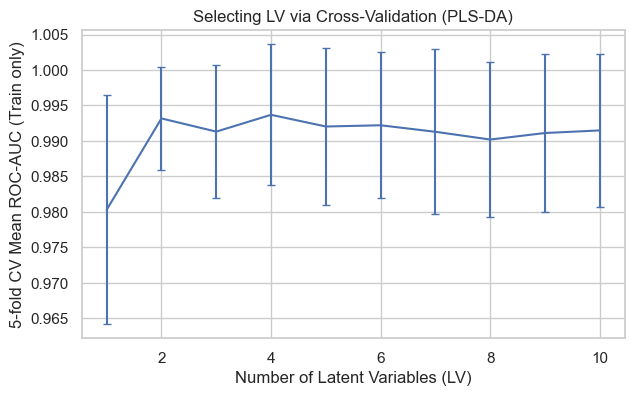


✅ the best optimized threshold level obtained from test set best_thr = 0.4477
Test ROC-AUC (only for tuning, not final): 0.9889


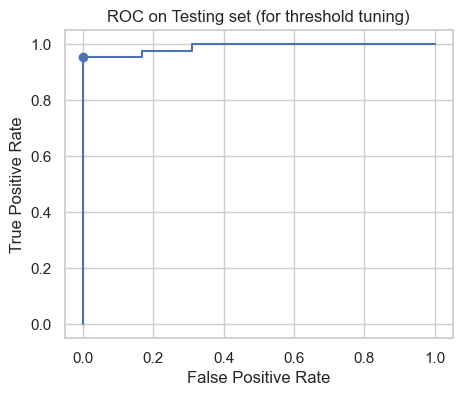


================= FINAL (Validation Set Only) =================
Confusion Matrix:
 [[72  0]
 [ 2 40]]
Accuracy    = 0.9825
Sensitivity = 0.9524  (恶性检出率，越高越少漏检)
Specificity = 1.0000  (良性识别率)
ROC-AUC     = 0.9944
PR-AUC      = 0.9924


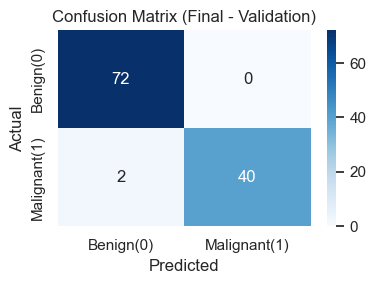

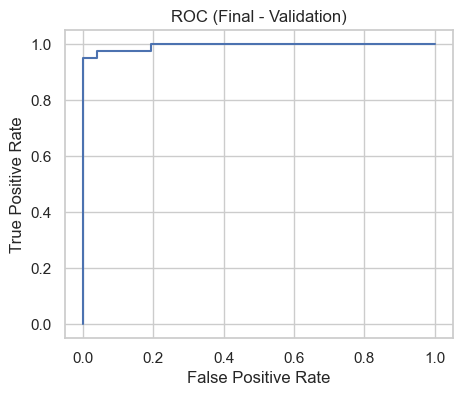

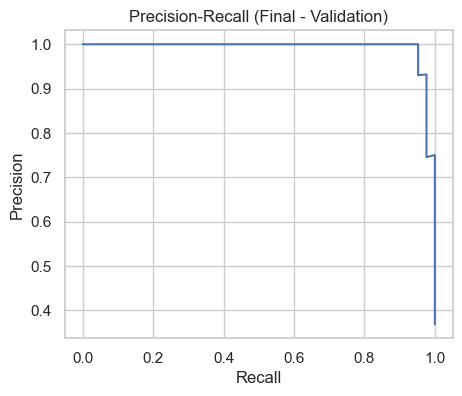

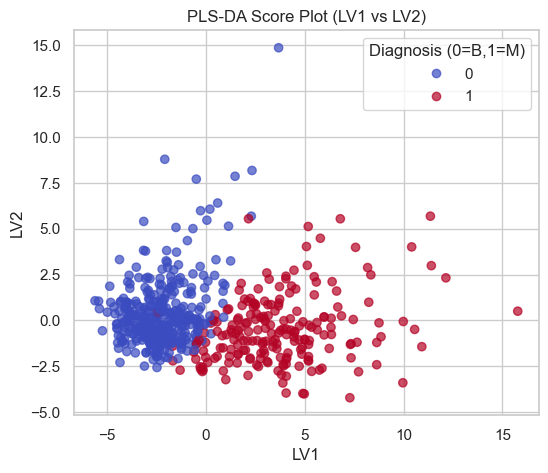


Top 10 VIP features:


,feature,VIP
27,concave points_worst,1.409697
20,radius_worst,1.404007
22,perimeter_worst,1.403902
7,concave points_mean,1.380496
2,perimeter_mean,1.327158
23,area_worst,1.315342
0,radius_mean,1.310553
3,area_mean,1.267173
6,concavity_mean,1.230833
26,concavity_worst,1.149302


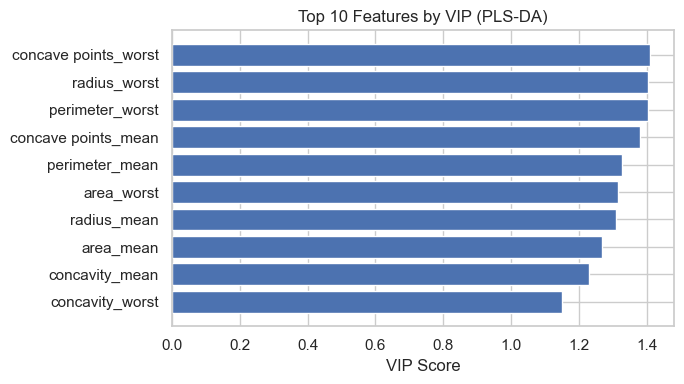

In [87]:
# =========================================================
# STEP 5  PLS-DA (Proper Validation: Train / Test / Validation)
# 目标：
# 1) Train：用交叉验证(CV)选择 LV 数（n_components）
# 2) Test ：用来“调阈值”(decision threshold)，但不作为最终成绩
# 3) Validation：最终性能评估（Accuracy/Sensitivity/Specificity + ROC-AUC/PR-AUC）
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression

from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

import seaborn as sns  # 你前面已经用过sns画混淆矩阵，这里继续用就行


# -------------------------
# 5.0 三份数据集划分（非常关键）
# -------------------------
# 注意：一定要 stratify=y（保持良/恶性比例一致）
# 这里我们做 60/20/20：Train 60%，Test 20%，Validation 20%

X_train_temp, X_val, y_train_temp, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train_temp, y_train_temp, test_size=0.25, random_state=42, stratify=y_train_temp
)
# 解释：先切出20%做val，剩下80%再切25%做test => 0.8*0.25=0.2，所以最终 train/test/val = 60/20/20

print("Train:", X_train.shape, "Test:", X_test.shape, "Validation:", X_val.shape)
print("Train class ratio:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test  class ratio:", y_test.value_counts(normalize=True).round(3).to_dict())
print("Val   class ratio:", y_val.value_counts(normalize=True).round(3).to_dict())


# -------------------------
# 5.1 在 Training set 上做 CV：选择 LV 数（n_components）
# -------------------------
# 我们用 ROC-AUC 做选择（比 accuracy 更稳定，因为不依赖阈值0.5）
# 你也可以改成 accuracy，但 AUC 更适合 PLS-DA 这种输出连续分数的模型。

def cv_select_n_components_plsda(X_train, y_train, max_lv=10, n_splits=5, random_state=42):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results = []

    for lv in range(1, max_lv + 1):
        fold_aucs = []

        for tr_idx, va_idx in cv.split(X_train, y_train):
            X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
            y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

            # ✅ 关键：scaler 只能在训练折上 fit（避免数据泄露）
            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_va_s = scaler.transform(X_va)

            pls = PLSRegression(n_components=lv)
            pls.fit(X_tr_s, y_tr)

            # PLS-DA 常见做法：把 y(0/1) 当作回归目标，输出连续分数，再用阈值转分类
            y_va_score = pls.predict(X_va_s).ravel()

            auc = roc_auc_score(y_va, y_va_score)
            fold_aucs.append(auc)

        results.append({
            "lv": lv,
            "cv_mean_auc": float(np.mean(fold_aucs)),
            "cv_std_auc": float(np.std(fold_aucs))
        })

    res_df = pd.DataFrame(results).sort_values("cv_mean_auc", ascending=False)
    best_lv = int(res_df.iloc[0]["lv"])
    return best_lv, res_df


best_lv, lv_table = cv_select_n_components_plsda(X_train, y_train, max_lv=10, n_splits=5)
print("\n[CV 结果] 不同 LV 的 5-fold CV ROC-AUC：")
display(lv_table.sort_values("lv"))

print(f"\n✅ the best optimized LV obtained from cross-validation = {best_lv}")


# （可选）画一下 LV vs CV AUC，放PPT很直观
plt.figure(figsize=(7,4))
plt.errorbar(lv_table.sort_values("lv")["lv"],
             lv_table.sort_values("lv")["cv_mean_auc"],
             yerr=lv_table.sort_values("lv")["cv_std_auc"],
             capsize=3)
plt.xlabel("Number of Latent Variables (LV)")
plt.ylabel("5-fold CV Mean ROC-AUC (Train only)")
plt.title("Selecting LV via Cross-Validation (PLS-DA)")
plt.grid(True)
plt.show()


# -------------------------
# 5.2 用 Training set 拟合模型；在 Testing set 上调阈值（decision threshold）
# -------------------------
# 说明：
# - 阈值默认 0.5 不一定最好
# - 我们在 test set 上用 ROC 曲线选择一个阈值（例如最大化 Youden's J = TPR - FPR）
# - 注意：test set 只能用于“调阈值”，不能作为最终成绩汇报

# 先 fit scaler（只用 train fit），并训练 PLS
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

pls = PLSRegression(n_components=best_lv)
pls.fit(X_train_s, y_train)

y_test_score = pls.predict(X_test_s).ravel()

# ROC 曲线，找最佳阈值（Youden's J）
fpr, tpr, thresholds = roc_curve(y_test, y_test_score)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_thr = thresholds[best_idx]

print(f"\n✅ the best optimized threshold level obtained from test set best_thr = {best_thr:.4f}")
print(f"Test ROC-AUC (only for tuning, not final): {roc_auc_score(y_test, y_test_score):.4f}")

# 可视化：Test ROC（可放PPT：说明你是用 test 调阈值）
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr)
plt.scatter(fpr[best_idx], tpr[best_idx])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC on Testing set (for threshold tuning)")
plt.grid(True)
plt.show()


# -------------------------
# 5.3 最终模型：用 Train+Test 重新训练；只在 Validation 上做最终评估
# -------------------------
# 逻辑：
# - 你已经用 train CV 选了 LV
# - 又用 test 调了阈值
# - 那最终模型就可以用 train+test 一起训练（让模型更稳）
# - 最终成绩只看 validation（完全没参与任何选择/调参）

X_train_test = pd.concat([X_train, X_test], axis=0)
y_train_test = pd.concat([y_train, y_test], axis=0)

scaler_final = StandardScaler()
X_train_test_s = scaler_final.fit_transform(X_train_test)
X_val_s        = scaler_final.transform(X_val)

pls_final = PLSRegression(n_components=best_lv)
pls_final.fit(X_train_test_s, y_train_test)

y_val_score = pls_final.predict(X_val_s).ravel()
y_val_pred  = (y_val_score >= best_thr).astype(int)

# 评估指标（最终只汇报这一组！）
cm = confusion_matrix(y_val, y_val_pred)
acc = accuracy_score(y_val, y_val_pred)

# Sensitivity/Specificity：以 1=Malignant 作为“阳性”
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn + 1e-12)   # Recall for malignant
specificity = tn / (tn + fp + 1e-12)   # True negative rate
roc_auc = roc_auc_score(y_val, y_val_score)

# PR-AUC（Average Precision）
pr_auc = average_precision_score(y_val, y_val_score)

print("\n================= FINAL (Validation Set Only) =================")
print("Confusion Matrix:\n", cm)
print(f"Accuracy    = {acc:.4f}")
print(f"Sensitivity = {sensitivity:.4f}  (恶性检出率，越高越少漏检)")
print(f"Specificity = {specificity:.4f}  (良性识别率)")
print(f"ROC-AUC     = {roc_auc:.4f}")
print(f"PR-AUC      = {pr_auc:.4f}")


# 可视化1：Validation 混淆矩阵
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign(0)", "Malignant(1)"],
            yticklabels=["Benign(0)", "Malignant(1)"])
plt.title("Confusion Matrix (Final - Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 可视化2：Validation ROC
fpr_v, tpr_v, _ = roc_curve(y_val, y_val_score)
plt.figure(figsize=(5,4))
plt.plot(fpr_v, tpr_v)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC (Final - Validation)")
plt.grid(True)
plt.show()

# 可视化3：Validation PR curve
precision, recall, _ = precision_recall_curve(y_val, y_val_score)
plt.figure(figsize=(5,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall (Final - Validation)")
plt.grid(True)
plt.show()


# -------------------------
# 5.4 PLS-DA Score Plot（LV1 vs LV2）——用于解释/对比 PCA
# -------------------------
# 重点：你可以依旧画 LV1 vs LV2 来对比 PCA(PC1 vs PC2)
# 即使 best_lv > 2，也仍然可以画前两个 LV 做可视化（只是模型内部还有更多 LV）

# 拿最终模型把所有样本投影到 latent space（注意：不重新fit，只transform）
X_all_s = scaler_final.transform(X)          # 用最终scaler变换
T_all = pls_final.transform(X_all_s)         # (n_samples, n_components)

plt.figure(figsize=(6,5))
sc = plt.scatter(T_all[:,0], T_all[:,1], c=y, cmap="coolwarm", alpha=0.7)
plt.xlabel("LV1")
plt.ylabel("LV2")
plt.title("PLS-DA Score Plot (LV1 vs LV2)")
plt.legend(*sc.legend_elements(), title="Diagnosis (0=B,1=M)")
plt.grid(True)
plt.show()


# -------------------------
# 5.5 VIP Plot（用最终模型算 VIP）
# -------------------------
# VIP 用来回答：哪些原始特征对区分 B/M 最重要（类似你想要的“解释性”）
# 注：这里的 VIP 是针对 PLS-DA 的，不是 Random Forest 的。

def calculate_vip(pls_model, X_scores, X_weights, Y_loadings):
    """
    计算 VIP（Variable Importance in Projection）
    - pls_model: 已fit的 PLSRegression
    - X_scores: T 矩阵 (n_samples, n_components)
    - X_weights: W 矩阵 (n_features, n_components)
    - Y_loadings: Q 矩阵 (n_targets, n_components) or (n_components,) 取决于实现
    """
    T = X_scores
    W = X_weights
    Q = Y_loadings

    # 统一形状
    if Q.ndim == 1:
        Q = Q.reshape(1, -1)

    p, A = W.shape  # p=特征数, A=成分数

    # 每个成分对Y的解释强度（SSY）
    # SSY_a = sum(T[:,a]^2) * sum(Q[:,a]^2)
    SSY = np.array([(T[:,a]**2).sum() * (Q[:,a]**2).sum() for a in range(A)])
    total_SSY = SSY.sum()

    vip = np.zeros((p,))
    for j in range(p):
        weight = np.array([(W[j,a]**2) * SSY[a] for a in range(A)]).sum()
        vip[j] = np.sqrt(p * weight / (total_SSY + 1e-12))

    return vip

vip_scores = calculate_vip(
    pls_final,
    X_scores=pls_final.x_scores_,
    X_weights=pls_final.x_weights_,
    Y_loadings=pls_final.y_loadings_
)

vip_df = pd.DataFrame({
    "feature": X.columns,
    "VIP": vip_scores
}).sort_values("VIP", ascending=False)

print("\nTop 10 VIP features:")
display(vip_df.head(10))

top_n = 10
vip_top = vip_df.head(top_n).sort_values("VIP", ascending=True)

plt.figure(figsize=(7,4))
plt.barh(vip_top["feature"], vip_top["VIP"])
plt.xlabel("VIP Score")
plt.title(f"Top {top_n} Features by VIP (PLS-DA)")
plt.tight_layout()
plt.show()


Block sizes: {'Mean block (_mean)': 10, 'SE block (_se)': 10, 'Worst block (_worst)': 10}


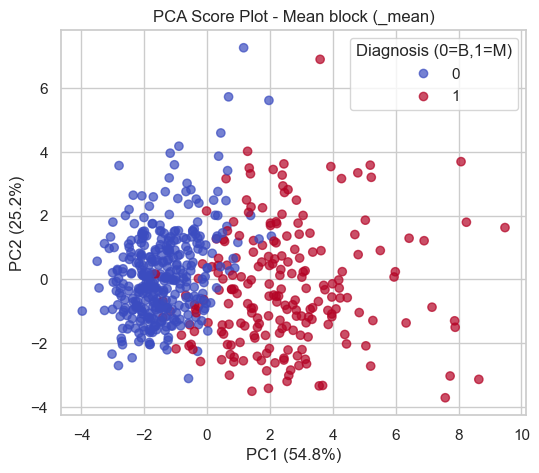

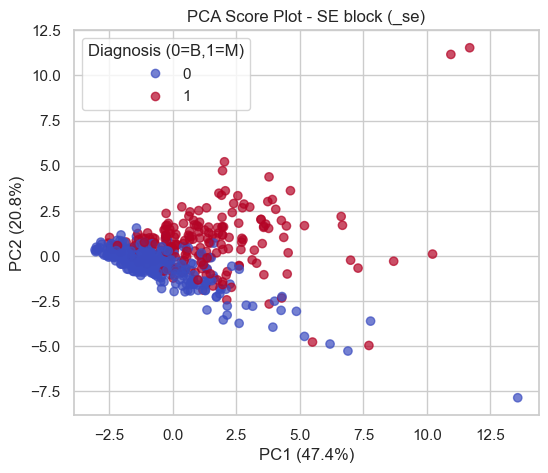

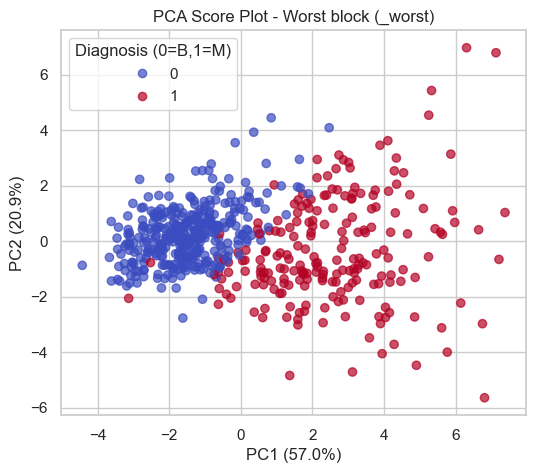


=== Mean block (_mean) ===
Top PC1 loadings:
concave points_mean    0.418038
concavity_mean         0.395748
perimeter_mean         0.376044
compactness_mean       0.364442
area_mean              0.364086
dtype: float64
Top PC2 loadings:
fractal_dimension_mean    0.571768
smoothness_mean           0.401962
symmetry_mean             0.368301
radius_mean              -0.313929
area_mean                -0.304842
dtype: float64

=== SE block (_se) ===
Top PC1 loadings:
concave points_se    0.385743
compactness_se       0.374799
perimeter_se         0.357481
concavity_se         0.355553
radius_se            0.345592
dtype: float64
Top PC2 loadings:
area_se                 0.500211
radius_se               0.440354
perimeter_se            0.420303
fractal_dimension_se   -0.352502
smoothness_se          -0.270953
dtype: float64

=== Worst block (_worst) ===
Top PC1 loadings:
concave points_worst    0.397637
concavity_worst         0.374742
compactness_worst       0.364568
perimeter_worst    

In [85]:
# STEP 17 Multiblock 每个 block 单独做 PCA + 分离图对比
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========== 1) 按后缀分块 ==========
cols_mean  = [c for c in X_scaled.columns if c.endswith("_mean")]
cols_se    = [c for c in X_scaled.columns if c.endswith("_se")]
cols_worst = [c for c in X_scaled.columns if c.endswith("_worst")]

blocks = {
    "Mean block (_mean)": X_scaled[cols_mean],
    "SE block (_se)": X_scaled[cols_se],
    "Worst block (_worst)": X_scaled[cols_worst],
}

print("Block sizes:", {k: v.shape[1] for k, v in blocks.items()})

# ========== 2) 每个block分别做PCA并画score plot ==========
def plot_block_pca_scores(X_block, y, title):
    pca = PCA(n_components=2)
    T = pca.fit_transform(X_block)  # score
    evr = pca.explained_variance_ratio_

    plt.figure(figsize=(6,5))
    sc = plt.scatter(T[:,0], T[:,1], c=y, cmap="coolwarm", alpha=0.7)
    plt.xlabel(f"PC1 ({evr[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({evr[1]*100:.1f}%)")
    plt.title(title)
    plt.legend(*sc.legend_elements(), title="Diagnosis (0=B,1=M)")
    plt.grid(True)
    plt.show()
    return pca

pca_models = {}
for name, Xb in blocks.items():
    pca_models[name] = plot_block_pca_scores(Xb, y, f"PCA Score Plot - {name}")

# ========== 3) 每个block输出PC1/PC2贡献最大的变量（用于解释） ==========
def top_loading_features(pca, cols, pc_index=0, top_n=5):
    # loadings = components_.T
    load = pd.Series(pca.components_[pc_index], index=cols)
    # 按绝对值排序，找最强贡献
    return load.reindex(load.abs().sort_values(ascending=False).index).head(top_n)

for name, pca in pca_models.items():
    cols = blocks[name].columns
    print(f"\n=== {name} ===")
    print("Top PC1 loadings:")
    print(top_loading_features(pca, cols, pc_index=0, top_n=5))
    print("Top PC2 loadings:")
    print(top_loading_features(pca, cols, pc_index=1, top_n=5))
